# This notebook must be run with the Vizgen_2 conda environment within the Vizgen.sif singularity container

In [1]:
import scanpy as sc
import loompy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import anndata
import seaborn as sns

In [2]:
base_path = '/oak/stanford/groups/quake/doug/MERFISH/Aging_Brain_Figshare/'
metas = [
    '24-mo-female-1-baysor/',
    '24-mo-female-3-baysor/',
    '24-mo-female-5-baysor/',
    '24-mo-male-1-baysor/',
    '24-mo-male-2-baysor/',
    '24-mo-male-4-rev2-baysor/',
    '3-mo-male-1-baysor/',
    '3-mo-male-2-baysor/',
    '3-mo-male-3-rev2-baysor/',
    '3-mo-female-1-rev2-baysor/',
    '3-mo-female-2-baysor/',
    '3-mo-female-3-baysor/'
]
adatas = []

# adding meta data columns into the adata.obs
for meta in metas:
    file_path = os.path.join(base_path, meta)
    # specifically use the baysor .loom files that are the right size
    loom_files = [f for f in os.listdir(file_path) if f.endswith('.loom') and '6-5' in f]
    if loom_files:
        loom_file = loom_files[0]  # Assuming there is only one .loom file (If you only ran one parameter of baysor)
        adata = sc.read_loom(os.path.join(file_path, loom_file))
        adata.obs['Age'] = meta.split('-')[0]
        adata.obs['Sex'] = meta.split('-')[2]
        adata.obs['batchID'] = meta.split('/')[0].replace("-baysor","")
        adata.var_names = adata.var.Name
        adata.obsm['spatial'] = adata.obs[["x", "y"]].values
        adatas.append(adata)

/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.

In [3]:
# combine together the anndata objects from each batch and generate gene counts per cell
combined_adata = anndata.concat(adatas, axis=0)

gene_counts_per_cell = combined_adata.X.getnnz(axis=1)

# Optionally, add this as a new column in `adata.obs`
combined_adata.obs['gene_counts'] = gene_counts_per_cell

/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


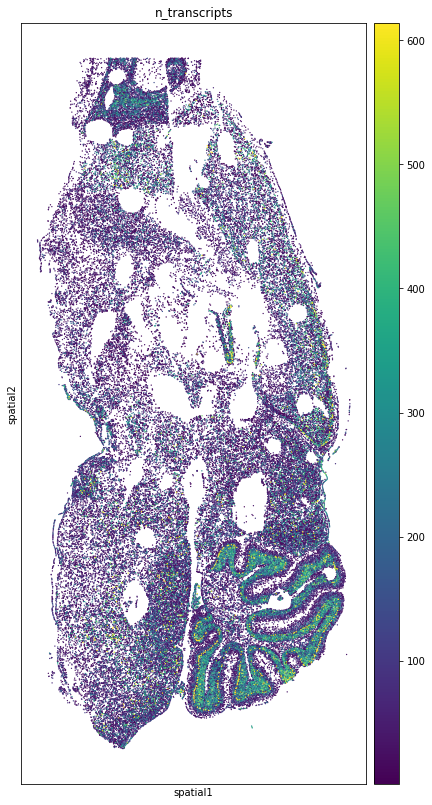

/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


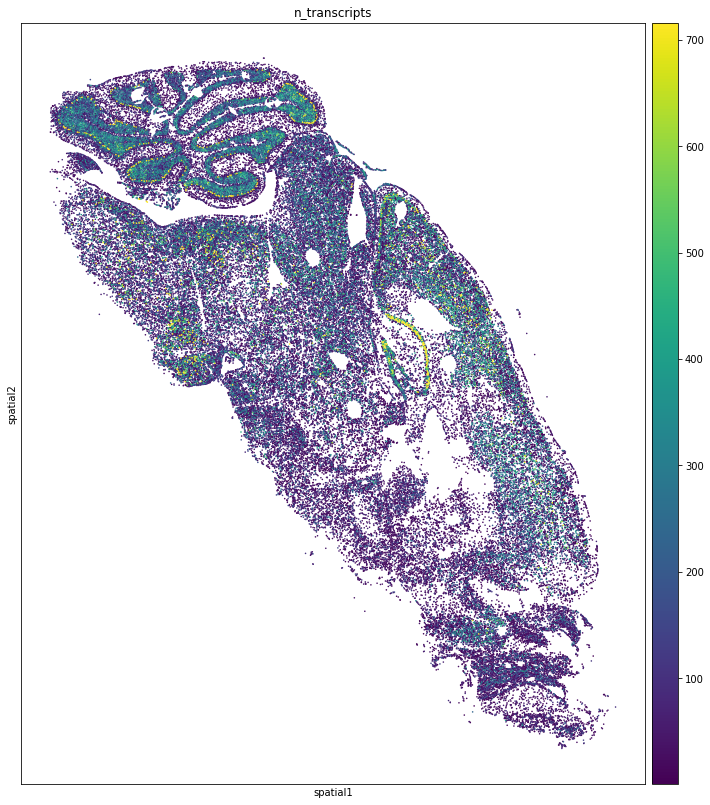

/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


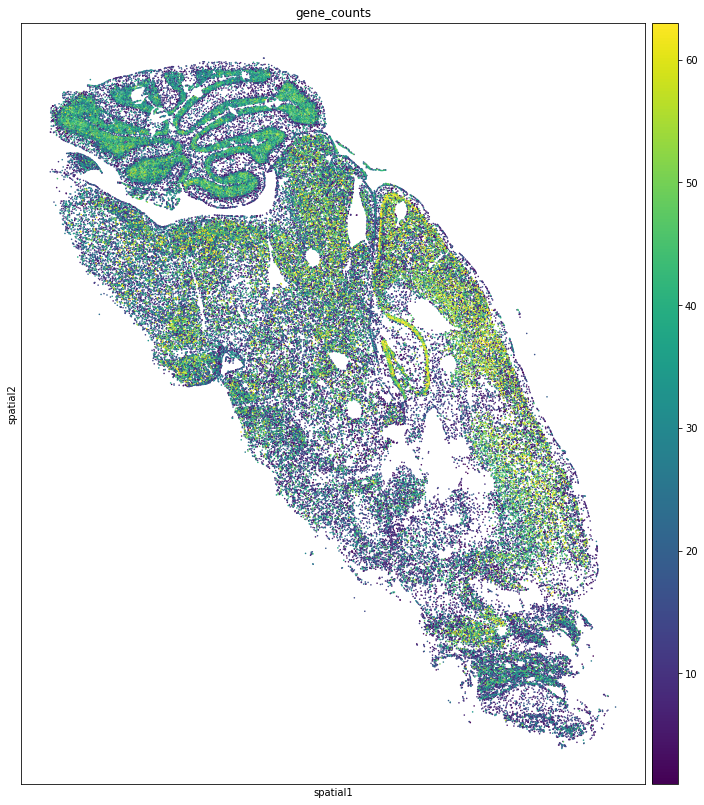

/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/oak/stanford/groups/quake/doug/resources/miniconda3/envs/Vizgen_2/lib/python3.9/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


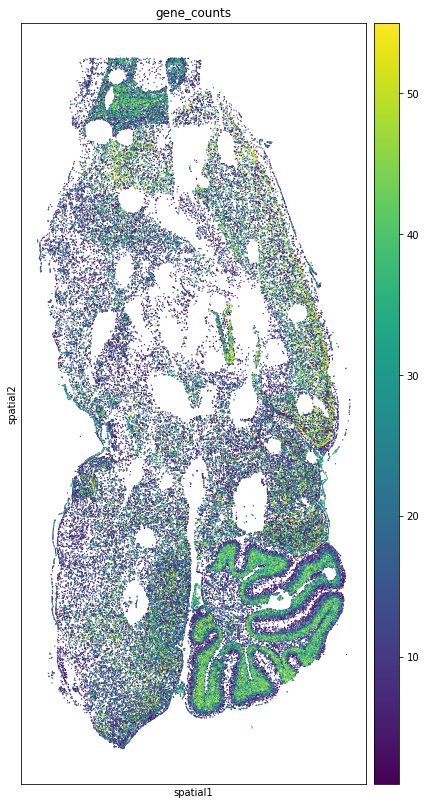

In [4]:
# We are just plotting and saving .pngs of representative slices for young and old brains
# want to show gene counts and transcripts per cell on the same brains

fig, ax = plt.subplots(figsize=(14,14))
sc.pl.spatial(combined_adata[combined_adata.obs.batchID == '24-mo-male-4-rev2'],cmap='viridis',color='n_transcripts',spot_size=25,ax=ax,vmax = "p99.5")
fig.savefig('old_n_transcripts.png', dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(14,14))
sc.pl.spatial(combined_adata[combined_adata.obs.batchID == '3-mo-female-1-rev2'],cmap='viridis',color='n_transcripts',spot_size=25,ax=ax,vmax = "p99.5")
fig.savefig('young_n_transcripts.png', dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(14,14))
sc.pl.spatial(combined_adata[combined_adata.obs.batchID == '3-mo-female-1-rev2'],color='gene_counts',spot_size=25,ax=ax,cmap='viridis',vmax = "p99.5")
fig.savefig('young_n_genes.png', dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(14,14))
sc.pl.spatial(combined_adata[combined_adata.obs.batchID == '24-mo-male-4-rev2'],cmap='viridis',color='gene_counts',spot_size=25,ax=ax,vmax = "p99.5")
fig.savefig('old_n_genes.png', dpi=300, bbox_inches='tight')